In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "3"

import numpy as np
import time
import torch

from datasets import build_dataset
from engine import train_one_epoch, evaluate
from losses import DistillationLoss
from samplers import RASampler

from compression.compress_vit import CompressedViT, create_compressed_deit_small
from timm.models import create_model

from utils import get_world_size, get_rank
from compression.hessian_core import *
from compression.new_prune_hessian import *

/home/chenzhiqiang/miniconda3/envs/det/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('--data-path', default='/home/chenzhiqiang/datasets/ImageNet', type=str,
                    help='dataset path')
parser.add_argument('--data-set', default='IMNET', choices=['CIFAR', 'IMNET', 'INAT', 'INAT19'],
                    type=str, help='Image Net dataset path')
parser.add_argument('--batch-size', default=64, type=int)
parser.add_argument('--num_workers', default=8, type=int)
parser.add_argument('--input-size', default=224, type=int, help='images input size')
parser.add_argument('--color-jitter', type=float, default=0.3, metavar='PCT',
                    help='Color jitter factor (default: 0.3)')
parser.add_argument('--aa', type=str, default='rand-m9-mstd0.5-inc1', metavar='NAME',
                    help='Use AutoAugment policy. "v0" or "original". " + \
                            "(default: rand-m9-mstd0.5-inc1)'),
parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')
parser.add_argument('--train-interpolation', type=str, default='bicubic',
                    help='Training interpolation (random, bilinear, bicubic default: "bicubic")')
parser.add_argument('--reprob', type=float, default=0.25, metavar='PCT',
                    help='Random erase prob (default: 0.25)')
parser.add_argument('--remode', type=str, default='pixel',
                    help='Random erase mode (default: "pixel")')
parser.add_argument('--recount', type=int, default=1,
                    help='Random erase count (default: 1)')
parser.add_argument('--resplit', action='store_true', default=False,
                    help='Do not random erase first (clean) augmentation split')
    
args = parser.parse_args(['--data-set', 'IMNET'])

In [3]:
model = create_model('deit_small_distilled_patch16_224', pretrained=True)
datasets, nb_classes = build_dataset(is_train=True, args=args)
num_tasks = get_world_size()
global_rank = get_rank()

sampler = torch.utils.data.DistributedSampler(
    datasets, num_replicas=num_tasks, rank=global_rank, shuffle=True
)

data_loader = torch.utils.data.DataLoader(
    datasets, sampler=sampler,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    pin_memory=False,
    drop_last=True,
)

In [4]:
analyzer = HessianAnalyzer(model, dataloader=data_loader)
temp = analyzer.analyze_layers_traces(maxIter=1)

import pickle
with open('layerwise_importance_analysis_result.pkl', 'wb') as f:
    pickle.dump(temp, f)

Analyzing layer: blocks.0.attn.qkv - GPU memory allocated: 85.90 MB
Analyzing layer: blocks.0.attn.qkv - GPU memory reserved: 108.00 MB
Analyzing layer: blocks.0.attn.qkv - GPU max memory allocated: 85.90 MB


Trace blocks.0.attn.qkv:   0%|          | 0/1 [00:00<?, ?it/s]/home/chenzhiqiang/miniconda3/envs/det/lib/python3.8/site-packages/torch/autograd/__init__.py:154: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at  /opt/conda/conda-bld/pytorch_1639180588308/work/torch/csrc/autograd/engine.cpp:976.)
  Variable._execution_engine.run_backward(
Trace blocks.0.attn.qkv: 100%|██████████| 1/1 [00:25<00:00, 25.35s/it]


Layer blocks.0.attn.qkv: trace = 57.183792
Analyzing layer: blocks.0.attn.proj - GPU memory allocated: 174.93 MB
Analyzing layer: blocks.0.attn.proj - GPU memory reserved: 2442.00 MB
Analyzing layer: blocks.0.attn.proj - GPU max memory allocated: 14971.33 MB


Trace blocks.0.attn.proj: 100%|██████████| 1/1 [00:25<00:00, 25.18s/it]


Layer blocks.0.attn.proj: trace = -171.498138
Analyzing layer: blocks.0.mlp.fc1 - GPU memory allocated: 174.44 MB
Analyzing layer: blocks.0.mlp.fc1 - GPU memory reserved: 2566.00 MB
Analyzing layer: blocks.0.mlp.fc1 - GPU max memory allocated: 14971.33 MB


...

Layer blocks.11.attn.proj: trace = 5.637697
Analyzing layer: blocks.11.mlp.fc1 - GPU memory allocated: 174.44 MB
Analyzing layer: blocks.11.mlp.fc1 - GPU memory reserved: 2568.00 MB
Analyzing layer: blocks.11.mlp.fc1 - GPU max memory allocated: 14971.33 MB


Trace blocks.11.mlp.fc1: 100%|██████████| 1/1 [00:17<00:00, 17.05s/it]


Layer blocks.11.mlp.fc1: trace = 16.358290
Analyzing layer: blocks.11.mlp.fc2 - GPU memory allocated: 174.38 MB
Analyzing layer: blocks.11.mlp.fc2 - GPU memory reserved: 2508.00 MB
Analyzing layer: blocks.11.mlp.fc2 - GPU max memory allocated: 14971.33 MB


Trace blocks.11.mlp.fc2: 100%|██████████| 1/1 [00:17<00:00, 17.36s/it]

Layer blocks.11.mlp.fc2: trace = 8.109039


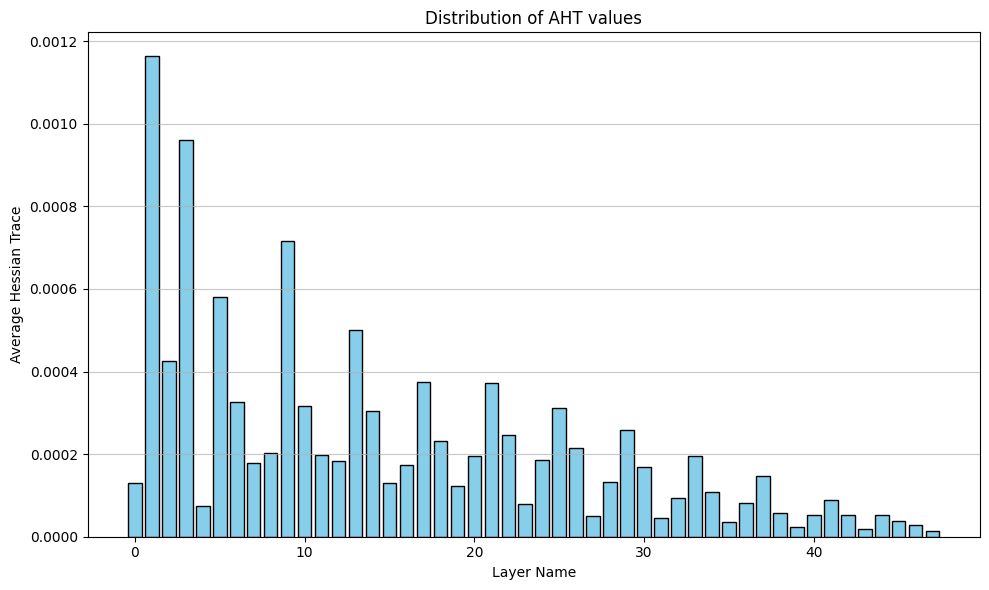

In [5]:
import matplotlib.pyplot as plt
data_to_plot = []
for k, v in analyzer.layer_results.items():
    data_to_plot.append(np.abs(v['importance']))

plt.figure(figsize=(10, 6))
plt.bar(range(len(data_to_plot)), data_to_plot, color='skyblue', edgecolor='black')
plt.title('Distribution of AHT values')
plt.xlabel('Layer Name')
plt.ylabel('Average Hessian Trace')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()

plt.show()

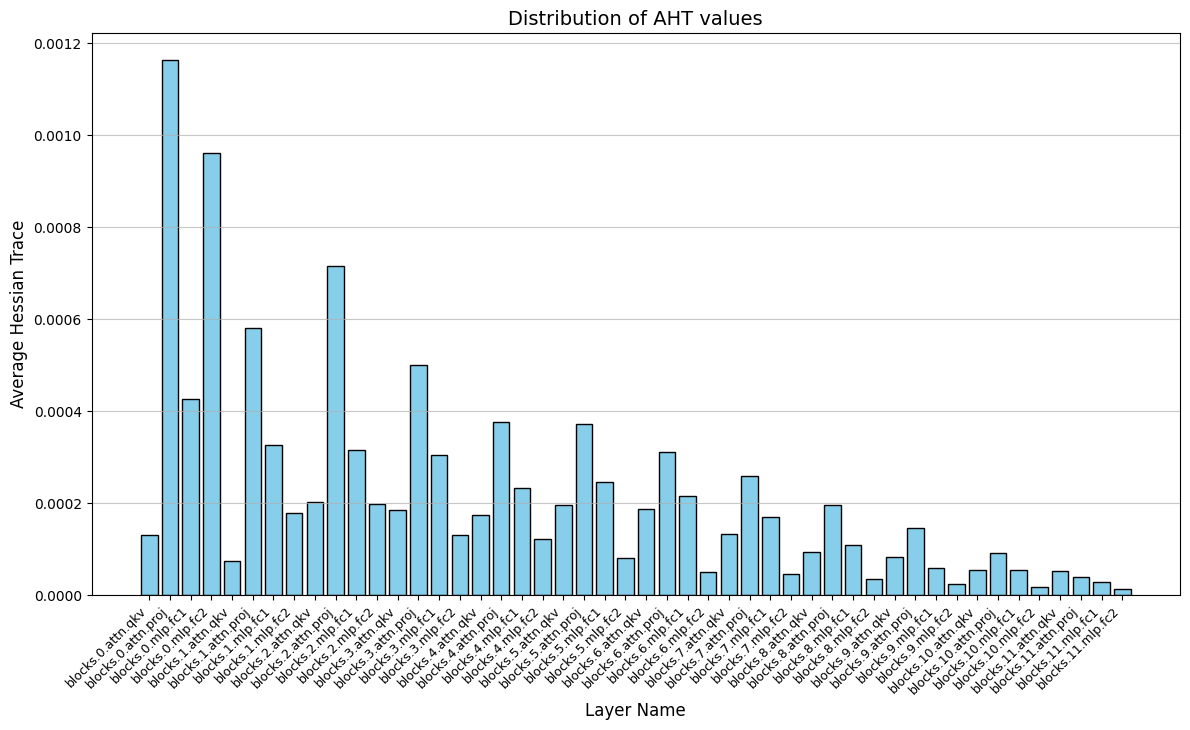

In [8]:
import matplotlib.pyplot as plt
import numpy as np

layer_names = list(analyzer.layer_results.keys())
data_to_plot = [np.abs(v['importance']) for k, v in analyzer.layer_results.items()]

plt.figure(figsize=(12, 8))  # 增加宽度以适应长标签

plt.bar(range(len(layer_names)), data_to_plot, color='skyblue', edgecolor='black')

plt.xticks(
    range(len(layer_names)), 
    layer_names, 
    rotation=45,          # 旋转45度避免重叠
    ha='right',           # 水平对齐方式
    fontsize=9            # 适当减小字体大小
)

plt.title('Distribution of AHT values', fontsize=14)
plt.xlabel('Layer Name', fontsize=12)
plt.ylabel('Average Hessian Trace', fontsize=12)
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # 增加底部边距

plt.show()

In [6]:
# Sort layerwise importance & gen sparse config
# sorted(analyzer.layer_results.items(), key=lambda x: x[1]['importance'], reverse=True)

sparse_budget = [0.4, 0.4, 0.2]
assert sum(sparse_budget) == 1.0, f"Expected sum of sparse budget to be 1.0, got {sum(sparse_budget)}"

split_point = np.percentile(np.array([v.get('importance') for v in analyzer.layer_results.values() if v.get('importance') is not None])
                            , np.cumsum(sparse_budget)[:-1] * 100)  # 1:1:1
less_imp_layer, mid_imp_layer, more_imp_layer = [], [], []
for name, val in analyzer.layer_results.items():
    if val.get('importance') is None:
        continue
    if val.get('importance') < split_point[0]:
        print(f"{name} is less important")
        less_imp_layer.append(name)
    elif val.get('importance') < split_point[1]:
        print(f"{name} is medium important")
        mid_imp_layer.append(name)
    else:
        print(f"{name} is more important")
        more_imp_layer.append(name)

blocks.0.attn.qkv is medium important
blocks.0.attn.proj is less important
blocks.0.mlp.fc1 is more important
blocks.0.mlp.fc2 is more important
blocks.1.attn.qkv is less important
blocks.1.attn.proj is more important
blocks.1.mlp.fc1 is more important
blocks.1.mlp.fc2 is medium important
blocks.2.attn.qkv is medium important
blocks.2.attn.proj is more important
blocks.2.mlp.fc1 is more important
blocks.2.mlp.fc2 is medium important
blocks.3.attn.qkv is medium important
blocks.3.attn.proj is more important
blocks.3.mlp.fc1 is medium important
blocks.3.mlp.fc2 is medium important
blocks.4.attn.qkv is medium important
blocks.4.attn.proj is more important
blocks.4.mlp.fc1 is medium important
blocks.4.mlp.fc2 is medium important
blocks.5.attn.qkv is medium important
blocks.5.attn.proj is more important
blocks.5.mlp.fc1 is medium important
blocks.5.mlp.fc2 is less important
blocks.6.attn.qkv is medium important
blocks.6.attn.proj is more important
blocks.6.mlp.fc1 is medium important
blocks

In [ ]:
# trace_vals = [val.get('importance') for val in analyzer.layer_results.values()]  # 关键修正！

# sparse_budget = [0.4, 0.4, 0.2]
# assert sum(sparse_budget) == 1.0, f"Expected sum of sparse budget to be 1.0, got {sum(sparse_budget)}"

# q = np.cumsum(sparse_budget)[:-1] * 100  # [0.4, 0.8] -> [40, 80]
# split_points = np.percentile(trace_vals, q)  # 返回 [p40, p80]

# less_imp_layer, mid_imp_layer, more_imp_layer = [], [], []
# for name, val in analyzer.layer_results.items():
#     trace_val = val['importance']  
#     if trace_val < split_points[0]:
#         less_imp_layer.append(name)
#     elif trace_val < split_points[1]:
#         mid_imp_layer.append(name)
#     else:
#         more_imp_layer.append(name)

In [7]:
import pickle

layer_group = {}
for layer in less_imp_layer:
    layer_group[layer] = 1  
for layer in mid_imp_layer:
    layer_group[layer] = 2  
for layer in more_imp_layer:
    layer_group[layer] = 3  
    
## Export Layer-wise importance & Sparse budget into pkl file
output_path = "deit_small_layerwise_importance_20251229.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(layer_group, f)

print(f"Successfully dumping result to : {output_path}")
print("Example Top 3 Layers:")
for layer, group in list(layer_group.items())[:3]:
    print(f"  {layer}: Group: {group} (Importance: {group}/3)")

Successfully dumping result to : deit_small_layerwise_importance_20251229.pkl
Example Top 3 Layers:
  blocks.0.attn.proj: Group: 1 (Importance: 1/3)
  blocks.1.attn.qkv: Group: 1 (Importance: 1/3)
  blocks.5.mlp.fc2: Group: 1 (Importance: 1/3)


In [ ]:
# analyzer.compute_importance_scores()
print(more_imp_layer)

In [ ]:
## plot layer-wise importance
import pickle

inp_path = "deit_small_layerwise_importance_20251229.pkl"
with open(inp_path, 'rb') as f:
    layer_imp = pickle.load(f)
    
print(layer_imp.shape)